# Fraud detection in Bank transaction
Author: David Moncivais | June 18 2026

## Introduction
### Objective
The objective of this project is to use the available data to train a model that detects fraud in bank transactions without using user identifying information (customer_id) in the process. A secondary objective is to use it as a practice exercise for data presentation, feature engineering, model selection, hyperparameter tuning, and the interpretation of results through data visualization.
### The data
The data is a large-scale synthetic banking dataset simulating 1,000,000 real-world financial transactions across 10 countries, designed for fraud detection and financial risk analysis. 
#### The overview
- **Rows**: 1,000,000
- **Columns**: 26
- **Fraud Rate**: ~5.5% (realistic imbalanced classification)
- **Time Period**: 2020 - 2024

## Data exploration
### First step: Data structure
Let's start this by getting the libraries that I'll be needing in conjunction with the data itself.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import gaussian_kde

In [29]:
data = './Data/bank_fraud.csv'
df = pd.read_csv(data)
df.head(5)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


Here we can see how the basic structure of the data is represented. Next, let's check the name of the columns we have at our disposition.

In [30]:
columns = df.columns
col_width = max(len(c) for c in columns) + 2
for i in range(0, len(columns), 5):
    print(''.join(c.ljust(col_width) for c in columns[i:i+5]))

transaction_id            customer_id               transaction_date          transaction_time          hour_of_day               
is_weekend                is_night_transaction      country                   city                      merchant_category         
payment_method            device_type               customer_age              credit_score              account_age_years         
account_balance           transaction_amount        num_prev_transactions     transaction_freq_monthly  distance_from_home_km     
time_since_last_txn_hrs   is_international          failed_attempts           pin_changed_recently      is_fraud                  
fraud_type                


First, we can see that the objective variable is going to be the *is_fraud* variable. As for our feature variables, without prior evidence, the best possible ones could be:
- customer_age (It could be that people of a certain age tend to get fraudulent charges more often.)
- payment_method (It is believed that people tend to get defrauded more through credit cards than debit cards, but is that the only two ways?)
- is_international (In this era of the internet, people can get scamed from people all over the world)
- failed_attempts (I think this number is the simplest indicator of a fraudulent transaction)
- pin_changed_recently (This is in case a fraudulent transaction is due to a hack into a bank or bank account)

Further down the line, with the research during this stage, we will see if these ones are ok or if some of the others are better.

### Second step: Studying the data
Now that I was able to see the data a little better, it's time to get some conclusions / observations out of it. First, let's get the description and info of the dataframe; this will help us see ranges, averages, data types, missing values, and if a feature has null values.

In [31]:
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.25442,204.724665,149.996350,19.999322,20.009890,12.000945,0.149994,0.380072,0.080439,0.055255
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.46068,459.567802,12.244379,4.474045,20.011427,11.999904,0.357066,0.914603,0.271972,0.228477
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.00000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.01750,33.400000,142.000000,17.000000,5.800000,3.450000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.12000,73.120000,150.000000,20.000000,13.900000,8.320000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.02500,181.450000,158.000000,23.000000,27.700000,16.630000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.00000,46129.600000,213.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

In [33]:
df.isnull().mean() * 100

transaction_id               0.0000
customer_id                  0.0000
transaction_date             0.0000
transaction_time             0.0000
hour_of_day                  0.0000
is_weekend                   0.0000
is_night_transaction         0.0000
country                      0.0000
city                         0.0000
merchant_category            0.0000
payment_method               0.0000
device_type                  0.0000
customer_age                 0.0000
credit_score                 0.0000
account_age_years            0.0000
account_balance              0.0000
transaction_amount           0.0000
num_prev_transactions        0.0000
transaction_freq_monthly     0.0000
distance_from_home_km        0.0000
time_since_last_txn_hrs      0.0000
is_international             0.0000
failed_attempts              0.0000
pin_changed_recently         0.0000
is_fraud                     0.0000
fraud_type                  94.4745
dtype: float64

The only null variable we have is *fraud_type*, understandable since we can see that apparently only 6% of the data represents a fraudulent type of transaction, so most of it shouldn't have a type.

With this code we can observe some of the ranges of the features already in mind for model training. For example, we can see that the age goes from 18 to 85 with a mean around 41. Also, we can see that it is probable that the variables failed_attempts and pin_changed_recently may not be of help since the mean of those 2 is too low and also the quartiles don't demonstrate a lot of changes in the data; they appear more as constants than variables themselves. Nevertheless, during the study of the data I'll be looking into whether they really won't be of any help.

Here are some functions that will help analyse different variables while saving time writing the same code over and over. The only difference between the two is that one works for categorical variables and the other for continuous ones.

In [34]:
def cat_vs_obj(df: pd.DataFrame, cat_variable: str, obj_variable: str = 'is_fraud'):
    total_fraud = len(df[df[obj_variable]==1])
    t1 = df[cat_variable].value_counts().reset_index().rename(columns={'count': 'Total'})
    t2 = df[df[obj_variable]==0][cat_variable].value_counts().reset_index().rename(columns={'count': 'Total no fraud'})
    t3 = df[df[obj_variable]==1][cat_variable].value_counts().reset_index().rename(columns={'count': 'Total fraud'})
    complete_t = t1.merge(t2, on = cat_variable, how = 'inner').merge(t3, on = cat_variable, how = 'inner')
    complete_t['Fraud %'] = complete_t['Total fraud'] / complete_t['Total'] * 100
    complete_t['Overall fraud %'] = complete_t['Total fraud'] / total_fraud * 100
    return complete_t.sort_values(by=['Overall fraud %'], ascending=False)

def con_vs_obj(df: pd.DataFrame, con_variable: str, title: str,x_name:str, obj_variable: str = 'is_fraud'):
    
    df_fraud = df[df[obj_variable] == 1][con_variable]
    df_no_fraud = df[df[obj_variable] == 0][con_variable]

    x_max = int(max(df[con_variable]))
    x_min = int(min(df[con_variable]))
    bins = 20
    xticks = [i for i in range(x_min, x_max+1, int((x_max - x_min)/bins)+1)]
    #yticks = [i/1000 for i in range(0,int(max_density*1000)+10,5)]

    plots = plt.figure(constrained_layout=True,figsize=(13, 7))
    gs = plots.add_gridspec(2, 2)

    total = plots.add_subplot(gs[0, :])
    total.set_title(title)
    total.hist(df[con_variable], bins = 20, color = 'Blue', density = True)
    total.set_xticks(xticks)
    #total.set_yticks(yticks)
    total.grid()

    fraud = plots.add_subplot(gs[1, 0])
    fraud.set_title('Fraud')
    fraud.hist(df_fraud, bins = 20, color = 'red', density = True)
    fraud.set_xticks(xticks)
    #fraud.set_yticks(yticks)
    fraud.grid()

    no_fraud = plots.add_subplot(gs[1, 1])
    no_fraud.set_title('No fraud')
    no_fraud.hist(df_no_fraud, bins = 20, color = 'Green', density = True)
    no_fraud.set_xticks(xticks)
    #no_fraud.set_yticks(yticks)
    no_fraud.grid()

    plots.supylabel('Density')
    plots.supxlabel(x_name)

#### Continuous Variable Analysis
In this section of the notebook, I'll look into the different continuous variables and compare their density across three aspects: the overall distribution density, the density distribution in non-fraudulent records, and the density distribution in fraudulent records. One of the previous functions will be helpful for this. The features to analyze are: customer age, the hour of day the transaction was made, the credit score of the account holder, and the distance from home where the transaction took place.

(None,)

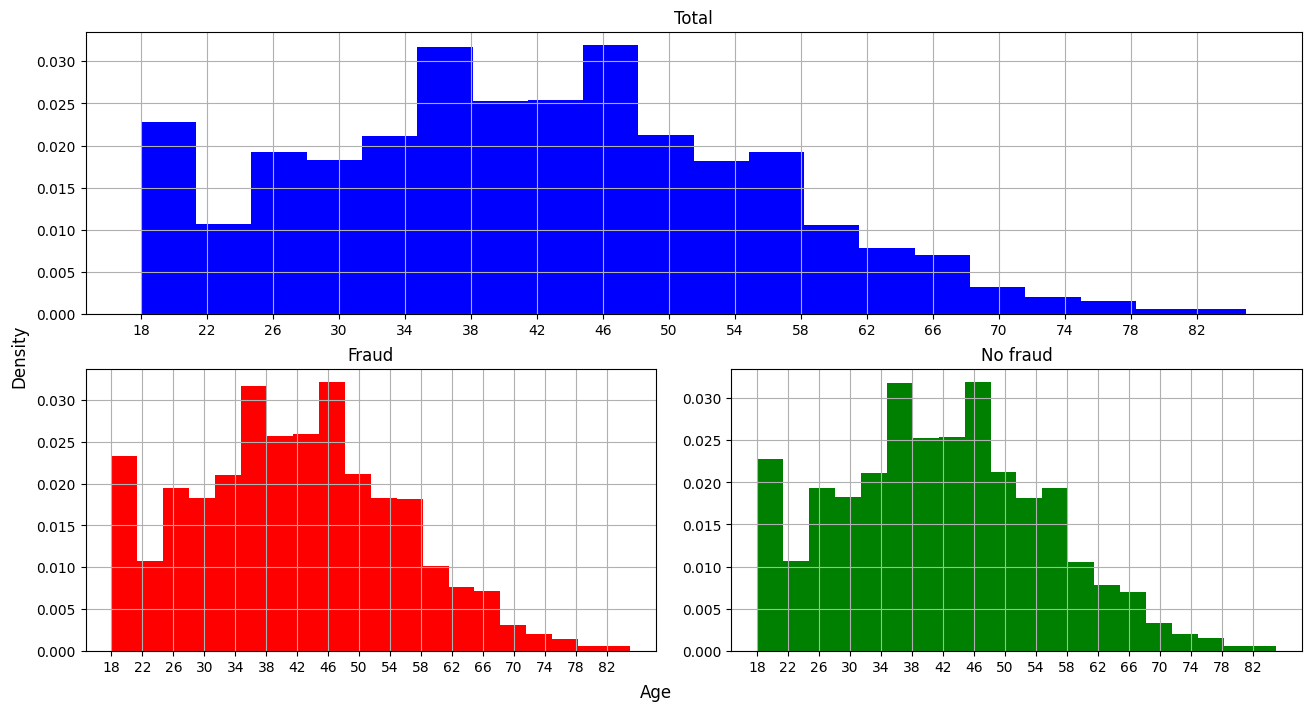

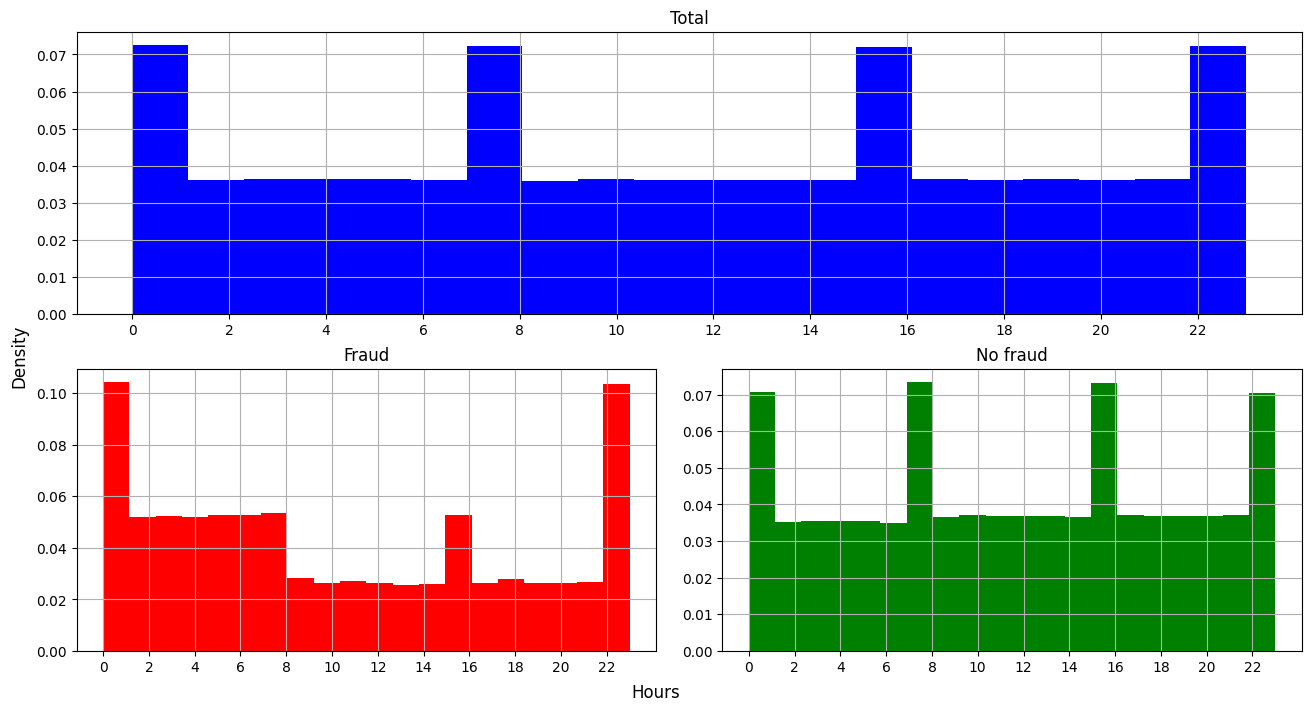

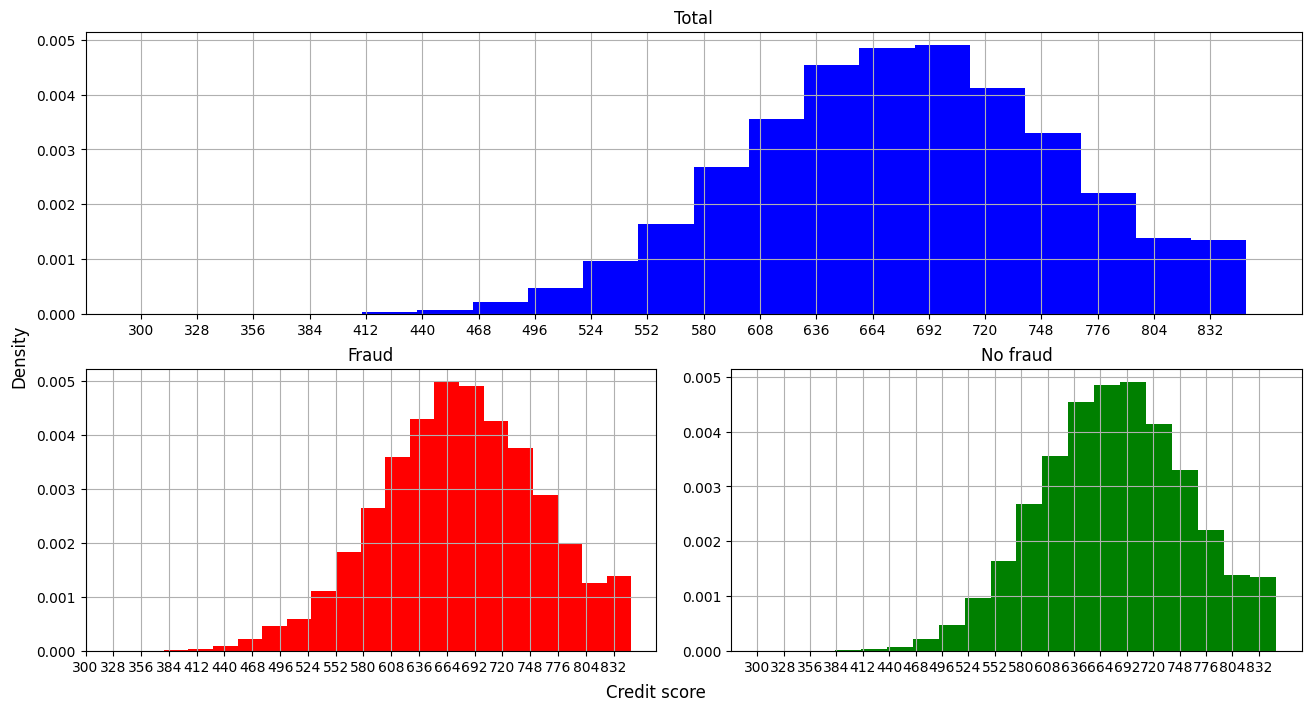

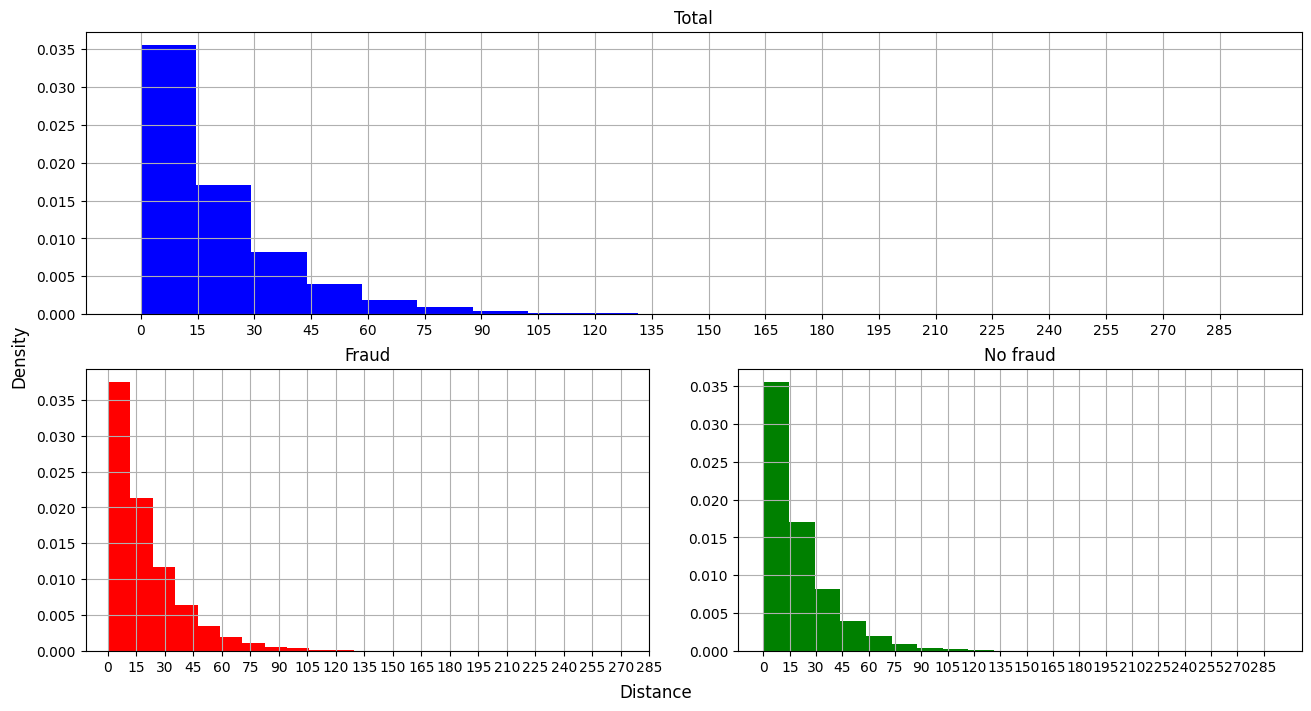

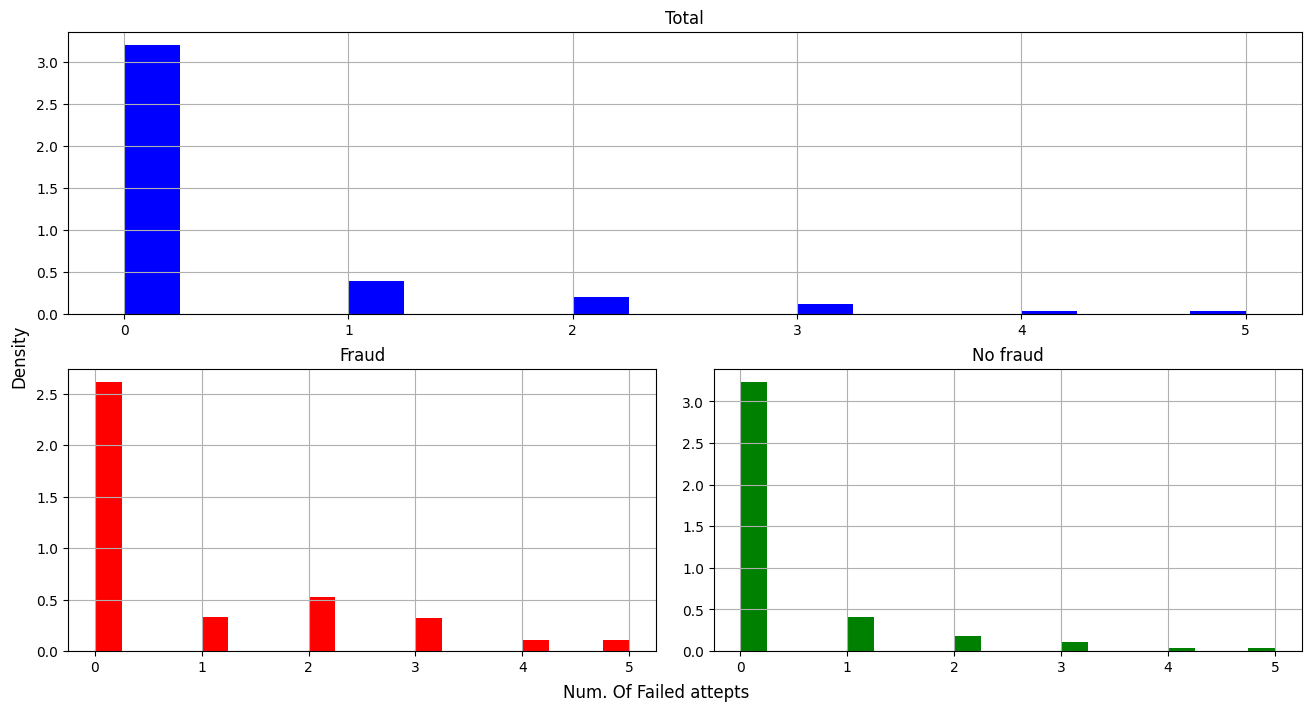

In [35]:
con_vs_obj(df, 'customer_age', 'Total', 'Age'),
con_vs_obj(df, 'hour_of_day', 'Total', 'Hours'),
con_vs_obj(df, 'credit_score', 'Total', 'Credit score'),
con_vs_obj(df, 'distance_from_home_km', 'Total', 'Distance'),
con_vs_obj(df, 'failed_attempts', 'Total', 'Num. Of Failed attepts'),

Looking at these plots, we can see that most continuous variables don't have a strong correlation with the target feature, since their densities remain similar across both classes. However, one variable does seem to show some correlation, as its distribution differs noticeably between fraud and non-fraud cases: the hour of the day the transaction took place. This makes it a good candidate variable for the model.

#### Categorical Variables Analysis
In this section, the study will focus on different categorical variables. Due to a limitation of the dataset being synthetic, two of the features, *country* and *city*, needed to be excluded since they don't make sense (i.e., one transaction may have country equal to France and city equal to Tokyo). Everything else is fair game.

In [36]:
display(cat_vs_obj(df=df, cat_variable='payment_method'), 
        cat_vs_obj(df=df, cat_variable='merchant_category'),
        cat_vs_obj(df=df, cat_variable='pin_changed_recently'),
        cat_vs_obj(df=df, cat_variable='device_type'),)

,payment_method,Total,Total no fraud,Total fraud,Fraud %,Overall fraud %
0,Credit Card,349618,330050,19568,5.596966,35.413990
1,Debit Card,300860,284440,16420,5.457688,29.716768
2,Bank Transfer,150029,141768,8261,5.506269,14.950683
3,Mobile Payment,119697,113129,6568,5.487188,11.886707
4,Crypto,50158,47400,2758,5.498624,4.991403
5,Cheque,29638,27958,1680,5.668399,3.040449


,merchant_category,Total,Total no fraud,Total fraud,Fraud %,Overall fraud %
1,Jewelry,66870,61049,5821,8.704950,10.534793
11,ATM Withdrawal,66389,60587,5802,8.739400,10.500407
14,Crypto Exchange,66308,60571,5737,8.652048,10.382771
3,Fuel,66843,63609,3234,4.838203,5.852864
2,Electronics,66866,63636,3230,4.830557,5.845625
5,Education,66816,63621,3195,4.781789,5.782282
6,Clothing,66792,63609,3183,4.765541,5.760565
0,Entertainment,67150,63999,3151,4.692480,5.702651
9,Healthcare,66613,63470,3143,4.718298,5.688173
12,Online Shopping,66341,63202,3139,4.731614,5.680934


,pin_changed_recently,Total,Total no fraud,Total fraud,Fraud %,Overall fraud %
0,0,919561,871034,48527,5.277192,87.823726
1,1,80439,73711,6728,8.364102,12.176274


,device_type,Total,Total no fraud,Total fraud,Fraud %,Overall fraud %
0,Mobile,449114,424090,25024,5.571859,45.288209
1,Desktop,249830,236165,13665,5.469719,24.730794
2,ATM,100995,95334,5661,5.605228,10.245227
3,Tablet,100101,94631,5470,5.464481,9.899557
4,POS Terminal,99960,94525,5435,5.437175,9.836214


These tables show that all of the categorical data inside the DataFrame tend to have a strong relationship with the target feature, making each one of them a candidate for use in the model.

### Third step: final conclusion about the data
After reviewing the results, we finally have a conclusive view on what is going to work for the model and what isn't. Based on the information observed, the variables that will be used as features in the model later on are:
- hour_of_day
- payment_method
- merchant_category
- pin_changed_recently
- device_type

## Data Preparation for Modeling

In this section, the data will be transformed so that I can finally start training the model. It will be code-heavy since most of the features are categorical and need to be converted to numerical values for training. The type of transformation they will undergo is target encoding, where each category value will be replaced with its Fraud %, similar to what was presented in the previous section — but this time the percentages will be calculated using cross-validation. But first, let's start by dividing the data into our training, validation, and test sets.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [38]:
df = df[['hour_of_day', 'payment_method', 'merchant_category', 'pin_changed_recently', 'device_type', 'is_fraud']]
train, val_test = train_test_split(df, test_size=0.2, random_state = 42)
val, test = train_test_split(val_test, test_size=0.5, random_state = 42)
len(train),len(val),len(test)

(800000, 100000, 100000)

In [39]:
train[:5]

,hour_of_day,payment_method,merchant_category,pin_changed_recently,device_type,is_fraud
566853,20,Debit Card,Education,0,POS Terminal,0
382311,16,Debit Card,Crypto Exchange,0,Desktop,0
241519,10,Cheque,Electronics,0,Desktop,1
719220,14,Debit Card,Utilities,0,POS Terminal,0
905718,17,Mobile Payment,Grocery,0,ATM,0


Now that I have my split, I can start to code the cross-validation procedure to substitute the categorical variables.

The procedure is simple: generate folds from the training set (10 in this case) and store them in a list. The function performs cross-validation by popping one fold, joining the rest, calculating the fraud % for each class within every feature, and adding that as a new column on the fold that was popped out. After that, the popped fold is appended back to the end of the list, so that the next iteration pops a new fold.

In [40]:
cats = ['payment_method', 'merchant_category', 'device_type']
folds = np.array_split(train, 10)

for i in range(len(folds)):
    fold = folds.pop(0)
    aux_df = pd.concat(folds).reset_index(drop=True)
        
    for c in cats:
        cat_df = cat_vs_obj(aux_df, c)[[c,'Fraud %']]
        fold[c+'_enc'] = fold[c].map(cat_df.set_index(c)['Fraud %'])
        
    folds.append(fold)
train = pd.concat(folds).reset_index(drop=True)

C:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


The next line serves as a way to verify that the procedure worked by comparing values from the top and bottom of the dataset. If it works correctly, the encoded features (columns with the '_enc' suffix) should have different values between the top and bottom rows that share the same categorical value.

In [41]:
display(train[:10], train[-10:])

,hour_of_day,payment_method,merchant_category,pin_changed_recently,device_type,is_fraud,payment_method_enc,merchant_category_enc,device_type_enc
0,20,Debit Card,Education,0,POS Terminal,0,5.502857,4.802694,5.469920
1,16,Debit Card,Crypto Exchange,0,Desktop,0,5.502857,8.740360,5.502803
2,10,Cheque,Electronics,0,Desktop,1,5.546147,4.725922,5.502803
3,14,Debit Card,Utilities,0,POS Terminal,0,5.502857,4.702214,5.469920
4,17,Mobile Payment,Grocery,0,ATM,0,5.481996,4.747145,5.634827
5,20,Credit Card,ATM Withdrawal,0,Desktop,0,5.607443,8.675809,5.502803
6,18,Debit Card,ATM Withdrawal,0,Mobile,0,5.502857,8.675809,5.577313
7,20,Mobile Payment,Restaurant,0,Mobile,0,5.481996,4.681589,5.577313
8,5,Crypto,ATM Withdrawal,0,Mobile,0,5.555094,8.675809,5.577313
9,0,Debit Card,Grocery,0,Desktop,0,5.502857,4.747145,5.502803


,hour_of_day,payment_method,merchant_category,pin_changed_recently,device_type,is_fraud,payment_method_enc,merchant_category_enc,device_type_enc
799990,14,Bank Transfer,Entertainment,0,Mobile,0,5.517612,4.768234,5.589103
799991,21,Cheque,Clothing,0,Mobile,0,5.673492,4.814560,5.589103
799992,14,Credit Card,ATM Withdrawal,1,Mobile,0,5.579956,8.705441,5.589103
799993,16,Credit Card,Electronics,0,Mobile,0,5.579956,4.742992,5.589103
799994,9,Debit Card,Electronics,0,POS Terminal,0,5.474666,4.742992,5.429877
799995,3,Credit Card,Restaurant,0,Tablet,0,5.579956,4.686979,5.490033
799996,0,Credit Card,Online Shopping,0,Mobile,0,5.579956,4.824204,5.589103
799997,15,Bank Transfer,ATM Withdrawal,0,POS Terminal,0,5.517612,8.705441,5.429877
799998,14,Credit Card,Healthcare,0,Desktop,0,5.579956,4.691764,5.478820
799999,16,Credit Card,Gaming,0,ATM,0,5.579956,4.698858,5.583290


Comparing the feature payment_method and its encoded counterpart in both tables — specifically rows 1, 3, and 799994 — the first two share the same value for "Debit Card" but their encoded values differ from row 799994, meaning the folds worked as intended.

Next, for the test and validation sets, the feature columns also need to be encoded, but according to the theory, not in the same way as with the training set. Instead, the whole training set is used to calculate the fraud % for each class within each column, similar to what I did when exploring the data. However, since I already have 10 different percentages for each class from the folds, taking a simple mean of those values works just as well.

In [42]:
for c in cats:
    mean_table = train[[c, c+'_enc']].groupby(c).mean()
    val[c+'_enc'] = val[c].map(mean_table[c+'_enc'])
    test[c+'_enc'] = test[c].map(mean_table[c+'_enc'])

Next, as before, I make sure the data was correctly implemented. Since the categorical encoding must be the same across both tables, there's no need to check the upper and lower sections of either one — I just need to verify that the encoding matches between the two tables.

In [43]:
val, test = val.reset_index(drop=True), test.reset_index(drop=True)
display(val[:5], test[:5])

,hour_of_day,payment_method,merchant_category,pin_changed_recently,device_type,is_fraud,payment_method_enc,merchant_category_enc,device_type_enc
0,8,Debit Card,Healthcare,0,Desktop,0,5.483187,4.661791,5.480172
1,23,Credit Card,Education,0,ATM,0,5.602372,4.734612,5.580291
2,4,Credit Card,Electronics,0,Mobile,0,5.602372,4.780089,5.575078
3,3,Debit Card,Jewelry,0,Mobile,0,5.483187,8.783553,5.575078
4,22,Mobile Payment,Education,0,Mobile,0,5.452405,4.734612,5.575078


,hour_of_day,payment_method,merchant_category,pin_changed_recently,device_type,is_fraud,payment_method_enc,merchant_category_enc,device_type_enc
0,22,Credit Card,Fuel,0,POS Terminal,0,5.602372,4.826502,5.446119
1,21,Credit Card,Entertainment,0,Desktop,0,5.602372,4.735150,5.480172
2,23,Credit Card,Entertainment,0,Mobile,0,5.602372,4.735150,5.575078
3,11,Mobile Payment,Online Shopping,1,Mobile,0,5.452405,4.758906,5.575078
4,6,Mobile Payment,Healthcare,1,Mobile,0,5.452405,4.661791,5.575078


Looking at the tables, specifically the first row of each, the encoding for payment_method matches, confirming that the training, validation, and test sets are ready to be used in a model.

## Model training
The training of the model is the pinnacle of this project. Based on the data and the objective of this work, the best candidates are either XGBoost or Random Forest, using Logistic Regression as a benchmark to compare the effectiveness of either model.

Before getting into benchmark test, separating the data into x's and y's is needed.

- X's meaning the entry point of the model
- Y's being the objective feature.

In [44]:
feature_col = ['hour_of_day', 'pin_changed_recently', 'payment_method_enc',	'merchant_category_enc', 'device_type_enc']
x_train, y_train = train[feature_col], train['is_fraud']
x_val, y_val = val[feature_col], val['is_fraud']
x_test, y_test = test[feature_col], test['is_fraud']

### Benchmark model: Logistic regression
Using the scikit-learn library, I'll be using their Logistic Regression model. I'm not just going to declare it and use it as-is — the idea is to get the best possible result so that it can later serve as a stronger benchmark for the target models. However, let's start simple by increasing max_iter for the model and see what we get.

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     94549
           1       0.00      0.00      0.00      5451

    accuracy                           0.95    100000
   macro avg       0.47      0.50      0.49    100000
weighted avg       0.89      0.95      0.92    100000



C:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Text(50.722222222222214, 0.5, 'Actual')

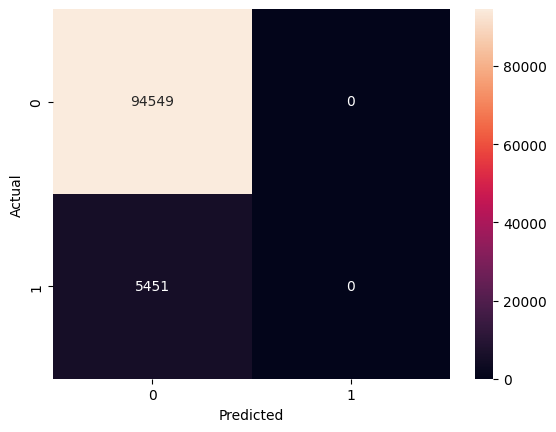

In [45]:
clf = LogisticRegression(random_state=0,  max_iter=1500).fit(x_train, y_train)
y_predict = clf.predict(x_val)
print(classification_report(y_val, y_predict))
sns.heatmap(confusion_matrix(y_val, y_predict), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

This first model, without much fine-tuning, gives us an accuracy of 94%. Based on this result alone, someone might be satisfied and leave it as is. However, it's not until we look at the confusion matrix that we notice none of the true fraud cases were predicted correctly — meaning that, for example, out of 100 real fraud cases, 0 were predicted.

Next, based on different experiments, I arrived at the following configuration to get the best results possible.
- class_weight is set to 'balanced', so that the model gives equal importance to both classes — something the previous model didn't do, simply defaulting to always predicting false.
- After trying different solvers, 'saga' was the one that gave the best results

              precision    recall  f1-score   support

           0       0.96      0.75      0.84     94549
           1       0.09      0.41      0.14      5451

    accuracy                           0.73    100000
   macro avg       0.52      0.58      0.49    100000
weighted avg       0.91      0.73      0.80    100000



C:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Text(50.722222222222214, 0.5, 'Actual')

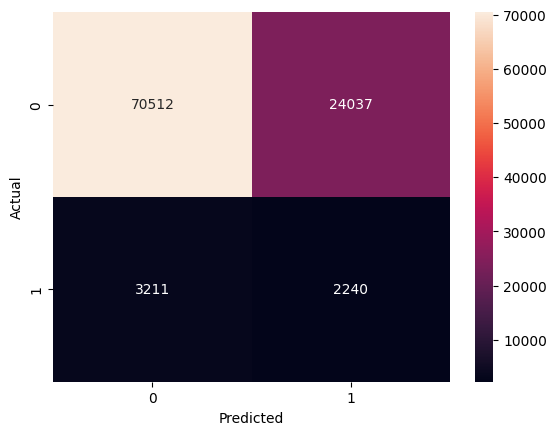

In [46]:
clf = LogisticRegression(random_state=0, class_weight='balanced', solver='saga', max_iter=1500)\
    .fit(x_train, y_train)
y_predict = clf.predict(x_val)
print(classification_report(y_val, y_predict))
sns.heatmap(confusion_matrix(y_val, y_predict), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

Here we can already see an improvement. The accuracy went down, but we have predictions for fraud cases; from the 5505 that are in the validation set, 2210 were predicted correctly, meaning less error in prediction of fraud, making a better model for the task at hand compared to the first one. Having said that, it is time to try it on the test set.

              precision    recall  f1-score   support

           0       0.95      0.75      0.84     94440
           1       0.08      0.39      0.14      5560

    accuracy                           0.73    100000
   macro avg       0.52      0.57      0.49    100000
weighted avg       0.91      0.73      0.80    100000



Text(50.722222222222214, 0.5, 'Actual')

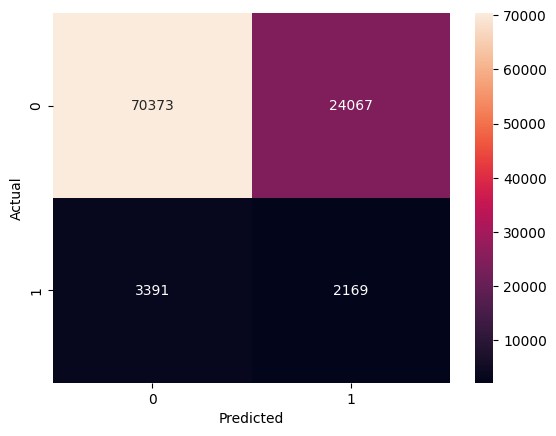

In [47]:
y_predict = clf.predict(x_test)
print(classification_report(y_test, y_predict))
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

This shows great results, since it appears that with the test set, the results didn't change much. We are still getting 40% of fraud cases categorized correctly and 75% of not fraud cases also categorized correctly. Having proven that the model works in the best way possible, it's now time to start testing the models that may be a better fit for resolving this issue.

### First model: RandomForestClassifier
Since one model represents the 'upgraded' version of the other, let's first try how well the v1 does. Random Forest trains a lot of decision trees independently from each other over random subsets of data and features, then combines their predictions to get a final result. A personal advantage I see in this model is that there aren't many hyperparameters to configure; a downside is that it's robust but slow.

In [48]:
from sklearn.ensemble import RandomForestClassifier

              precision    recall  f1-score   support

           0       0.97      0.49      0.65     94549
           1       0.08      0.74      0.14      5451

    accuracy                           0.50    100000
   macro avg       0.52      0.61      0.39    100000
weighted avg       0.92      0.50      0.62    100000



Text(50.722222222222214, 0.5, 'Actual')

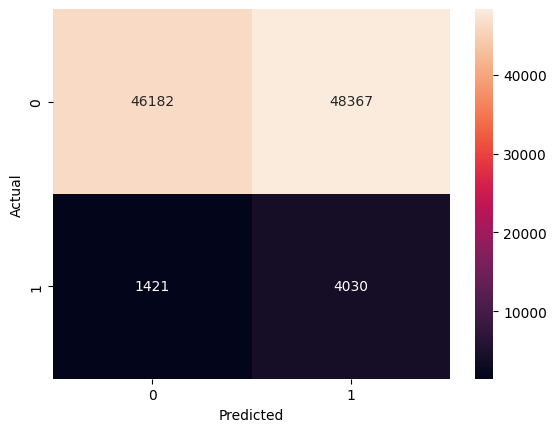

In [50]:
model = RandomForestClassifier(n_estimators=500, max_depth=10,class_weight='balanced').fit(x_train, y_train)
y_predict = model.predict(x_val)
print(classification_report(y_val, y_predict))
sns.heatmap(confusion_matrix(y_val, y_predict), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

After several configurations, this was the best one. Having 300 estimators generating answers, each one with a depth of 10, and making sure that the weight of both classes was balanced resulted in a less accurate model overall — with 50% accuracy — but an increase in successful fraud predictions to 74% but a succesful rate of not fraud prediction of 49%.

### Second model: XGBoost
The second model is an upgrade of the first. The main difference between Random Forest and this model is that Random Forest trains the trees independently and averages the decisions based on the results given. XGBoost doesn't do that — it builds the trees sequentially, where each tree corrects the model based on the errors of the previous tree.

In [21]:
from xgboost import XGBClassifier

              precision    recall  f1-score   support

           0       0.97      0.55      0.70     94549
           1       0.08      0.66      0.14      5451

    accuracy                           0.56    100000
   macro avg       0.52      0.60      0.42    100000
weighted avg       0.92      0.56      0.67    100000



Text(50.722222222222214, 0.5, 'Actual')

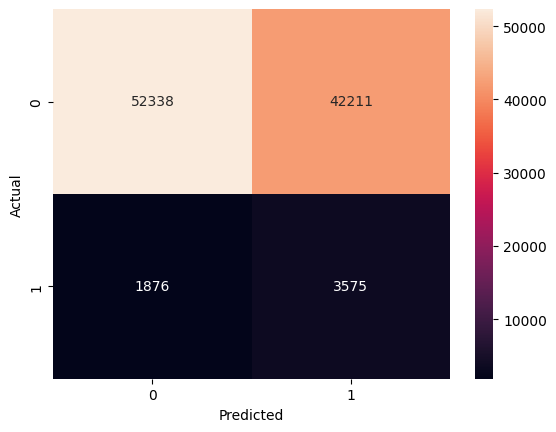

In [27]:
model = XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=10, scale_pos_weight = 17.3452, eval_metric = 'aucpr').fit(x_train, y_train)
y_predict = model.predict(x_val)
print(classification_report(y_val, y_predict))
sns.heatmap(confusion_matrix(y_val, y_predict), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')